In [208]:
import numpy as np
import pandas as pd
from tqdm import trange
import utm
import time
import os
import pickle as pkl
import inspect

from obspy import read

from obspy.clients.fdsn import Client

# import UTCDateTime from obspy
from obspy.core.utcdatetime import UTCDateTime as UTC
from obspy.core.event.catalog import read_events
import datetime
import matplotlib.pyplot as plt

from haversine import haversine, Unit
import math

In [102]:
cat_dir = "/Users/ivandevert/projects/ridgecrest2019/data/catalogs/"
eloc_catalog_path = "/Users/ivandevert/projects/ridgecrest2019/data/trugman_ridgecrest2019_relocated_catalog.txt"

In [227]:
class MiniseedReader:
    def __init__(self, seismogram_paths):
        self.seismogram_paths = seismogram_paths

def obspy_catalog_to_df(catalog, client_format='SCEDC'):

    event_name = []
    station_name = []
    pick_phase = []
    pick_time = []


    for i in trange(len(catalog)):
        ev = catalog[i]
        ename = int(ev.resource_id.id.split('=')[-1])

        picks = ev.picks
        sname = [[]] * len(picks)
        pphase = [[]] * len(picks)
        ptime = [[]] * len(picks)
        for p, pick in enumerate(picks):
            sname[p] = pick.waveform_id.id
            pphase[p] = pick.phase_hint
            ptime[p] = pick.time.datetime

        event_name += [ename] * len(picks)
        station_name += sname
        pick_phase += pphase
        pick_time += ptime

    df = pd.DataFrame(
        {
            'event_name':       event_name,
            'station_name':     station_name,
            'pick_phase':       pick_phase,
            'pick_time':        pick_time
        }
    )
    
    # sort by event_name
    df = df.sort_values(by='event_name').reset_index(drop=True)

    return df

# compute distances between events and stations in km
def geo_distance(lat1, lon1, lat2, lon2):
    earth_radius = 6371.0
    # Convert all angles to radians
    lat1_r = np.deg2rad(lat1)
    lon1_r = np.deg2rad(lon1)
    lat2_r = np.deg2rad(lat2)
    lon2_r = np.deg2rad(lon2)
    # Calculate the distance
    dp = np.cos(lat1_r) * np.cos(lat2_r) * np.cos(lon1_r - lon2_r) + np.sin(lat1_r) * np.sin(lat2_r)
    angle = np.arccos(dp)
    return earth_radius * angle

# df_picks = obspy_catalog_to_df(cat1)
# with open(f"{cat_dir}picks_scedc.pkl", 'wb') as fs:
#     pkl.dump(df_picks, fs)


In [239]:
# each of these dirs contains folders, one per event, containing seismograms, one per station
dirs_containing_events = [
    "/Volumes/ianhdd/LaCie/ridgecrest_data/RC_M2.0to2.5/",
    "/Volumes/ianhdd/LaCie/ridgecrest_data/RC_M3above/"
]

# earthquake location catalog (Trugman 2020)
eloc_catalog_path = "/Users/ivandevert/projects/ridgecrest2019/data/trugman_ridgecrest2019_relocated_catalog.txt"

p_traveltime_path = "/Users/ivandevert/projects/ridgecrest2019/data/out.ttP"
s_traveltime_path = "/Users/ivandevert/projects/ridgecrest2019/data/out.ttS"


In [105]:
# First, get all the dirs of the events
event_dirs = []
for d in dirs_containing_events:
    event_dirs += [os.path.join(d,f)+"/" for f in os.listdir(d) if os.path.isdir(os.path.join(d,f))]
# event_names = [event_dirs[i].split('/')[-1] for i in range(len(event_dirs))]

# Get all paths of seismograms
seismogram_paths = []
for i in trange(len(event_dirs)):
    d = event_dirs[i]
    seismogram_paths += [os.path.join(d,f) for f in os.listdir(d) if f.endswith('.ms')]


100%|██████████| 1542/1542 [00:26<00:00, 57.57it/s]


In [106]:
event_names, record_names = np.array(
    [fp.split('/')[-2:] for fp in seismogram_paths]
    ).T
sta, net, cha, loc, syr, jday, hms, event_name, ms = np.array(
    [record_names[i].split('.') for i in range(len(record_names))]
    ).T

event_names = np.array(event_names, dtype=int)
station_names = np.array(
    ['.'.join([net[i], sta[i], loc[i], cha[i]]) for i in range(len(sta))]
    )


In [107]:
st = read(event_dirs[0]+"*.ms")
st_cat = read_events(event_dirs[0]+"*.xml")

TypeError: Unknown format for file /Volumes/ianhdd/LaCie/ridgecrest_data/RC_M2.0to2.5/38489455/38489455.iris.xml

In [ ]:


# begin process

ev_dep = []
st_dep = []
rec_dep = []

client_iris = Client('IRIS')
client_scedc = Client('SCEDC')
client_ncedc = Client('NCEDC')

df_files = pd.DataFrame(
    {
        'event_name':       event_names,
        'station_name':     station_names
    }
)
ev_dep += ['event_name']
st_dep += ['station_name']

df_files_ev = df_files.groupby(ev_dep, as_index=False)[st_dep].agg(list)
# df_st = df_files.groupby(st_dep, as_index=False)[ev_dep].agg(list)


In [ ]:
starttime = '2019-07-01T00:00:00.000000Z'
endtime = '2019-07-20T00:00:00.000000Z'
minmagnitude = 0.9
maxmagnitude = 9.0
minlongitude = -118.0
maxlongitude = -117.0
minlatitude = 35.0
maxlatitude = 37.0

bulk_dt_hours = 6

# split into days
t0_utc = UTC(starttime)
t1_utc = UTC(endtime)
iters = int(np.ceil((t1_utc - t0_utc) / (3600*bulk_dt_hours)))

clients = ["SCEDC", "IRIS"]

# check if catalog already exists
download_catalog = False
for cname in clients:
    if not os.path.exists(f"{cat_dir}picks_{cname.lower()}.pkl"):
        download_catalog = True
        print("will download catalog")

if download_catalog:
    for cname in clients:
        print(f"Downloading data from client {cname}...")
        client = Client(cname)
        cat = None
        for i in trange(int(iters)):
            t0 = t0_utc + i*3600*bulk_dt_hours
            t1 = t0_utc + (i+1)*3600*bulk_dt_hours
            try:
                cat_part = client.get_events(
                    starttime=str(t0),
                    endtime=str(t1),
                    minmagnitude=minmagnitude,
                    maxmagnitude=maxmagnitude,
                    minlongitude=minlongitude,
                    maxlongitude=maxlongitude,
                    minlatitude=minlatitude,
                    maxlatitude=maxlatitude,
                    includearrivals=True
                    )
                if cat:
                    cat += cat_part
                else:
                    cat = cat_part
            except Exception as e:

                # no data error (no events in timeframe)
                if e.status_code==204:
                    pass
                else:
                    print(e)

        # takes sooooo long
        # cat.write(cat_dir + f'catalog_{cname.lower()}.xml', format='quakeml')

        df_picks = obspy_catalog_to_df(cat)
        with open(f"{cat_dir}picks_{cname.lower()}.pkl", 'wb') as fs:
            pkl.dump(df_picks, fs)

df_picks = None

for cname in clients:
    with open(f"{cat_dir}picks_{cname.lower()}.pkl", 'rb') as fs:
        if df_picks is not None:
            df_picks = pd.concat([df_picks, pkl.load(fs)])
        else:
            df_picks = pkl.load(fs)
df_picks = df_picks.reset_index(drop=True)
df_picks['event_name'] = df_picks['event_name'].astype(int)
# this might have multiple entries for the same record/phase combo

In [ ]:
# download station information, or load from file

download_stations = False
if not os.path.exists(f"{cat_dir}inv_ridgecrest.pkl"):
    download_stations = True
    print("will download station information")
    raise NotImplementedError("not written yet")
else:
    with open(f"{cat_dir}inv_ridgecrest.pkl", 'rb') as fs:
        df_stations = pkl.load(fs)

In [99]:

# Load Trugman (2020) earthquake relocations
df_locations = pd.read_csv(
    eloc_catalog_path,
    sep=r'\s+',
    skiprows=28,
    header=None,
    names=[
        'event_name', 'ymd', 'hms', 'emag', 'elon', 'elat', 'edep', 'relocated'
        ],
    dtype={
        'event_name': int,
        'ymd': str,
        'hms': str,
        'emag': float,
        'elon': float,
        'elat': float,
        'edep': float,
        'relocated': bool,
        }
)
df_locations['etime'] = df_locations['ymd'] + 'T' + df_locations['hms'] + "Z"
df_locations['etime'] = [UTC(el).datetime for el in df_locations['etime'].values]
df_locations.drop(columns=['ymd', 'hms'], inplace=True)
# sort by event_name
df_locations = df_locations.sort_values(by='event_name').reset_index(drop=True)

In [228]:
# Now, I have four dataframes:
# 1) df_files: all downloaded seismograms (event_name, station_name)
# 2) df_picks: all cataloged picks (event_name, station_name, pick_phase, pick_time)
# 3) df_locations: all event locations (event_name, emag, elon, elat, edep, etime)
# 4) df_stations: all station information (station_name, slat, slon, sele, local_depth, sample_rate, sdip, sazi)
#
# First, merge picks into df
df = df_files.copy()
ev_dep = ['event_name']
st_dep = ['station_name']
rec_dep = []
print(f"Number of seismograms loaded: {len(df):,}")

# df = pd.merge(df, df_picks, how='left', on=['event_name', 'station_name'])

# Separate P and S picks
df_p = df_picks.copy()
df_s = df_picks.copy()

# drop rows with 'S' pick_phase from df_p
df_p = df_p[df_p['pick_phase'] == 'P'].reset_index(drop=True)
df_s = df_s[df_s['pick_phase'] == 'S'].reset_index(drop=True)

# rename pick_time to pick_p or pick_s
df_p.rename(columns={'pick_time': 'p_arrival'}, inplace=True)
df_s.rename(columns={'pick_time': 's_arrival'}, inplace=True)

# drop pick_phase
df_p.drop(columns=['pick_phase'], inplace=True)
df_s.drop(columns=['pick_phase'], inplace=True)

print(f"Number of P picks from downloaded catalog: {len(df_p):,}")
print(f"Number of S picks from downloaded catalog: {len(df_s):,}")

# merge df_p and df_s together into df_pk using both 

# merge both into df
df = pd.merge(df, df_p, how='left', on=['event_name', 'station_name'])
df = pd.merge(df, df_s, how='left', on=['event_name', 'station_name'])

# fill NaN with 0
df.fillna(UTC(0).datetime, inplace=True)
rec_dep += ['p_arrival', 's_arrival']

# group by event
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+rec_dep].agg(list)

# merge df_locations into df_ev
df_ev = pd.merge(df_ev, df_locations, how='left', on=ev_dep)
ev_dep += ['emag', 'elon', 'elat', 'edep', 'relocated', 'etime']

print(f"Number of events loaded from Trugman (2020): {len(df_locations):,}")

# explode
df = df_ev.explode(st_dep+rec_dep).reset_index(drop=True)

# group by stations
df_st = df.groupby(st_dep, as_index=False)[ev_dep+rec_dep].agg(list)

# merge station information
df_st = pd.merge(df_st, df_stations, how='left', on=st_dep)

print(f"Number of stations/channels loaded from downloaded inventory: {len(df_stations):,}")
print(f"Number of stations/channels used: {len(df_st):,}")

st_dep += ['slat', 'slon', 'sele', 'local_depth', 'sample_rate', 'sdip', 'sazi']

df = df_st.explode(ev_dep+rec_dep).reset_index(drop=True)

df['rec_dist'] = geo_distance(
    df['elat'].values.astype(float), 
    df['elon'].values.astype(float), 
    df['slat'].values.astype(float), 
    df['slon'].values.astype(float)
)
rec_dep += ['rec_dist']

df_ev = df.groupby(ev_dep, as_index=False)[st_dep+rec_dep].agg(list)
df_st = df.groupby(st_dep, as_index=False)[ev_dep+rec_dep].agg(list)


Number of seismograms loaded: 371,279
Number of P picks from downloaded catalog: 424,375
Number of S picks from downloaded catalog: 307,692
Number of events loaded from Trugman (2020): 12,943
Number of stations/channels loaded from downloaded inventory: 11,441
Number of stations/channels used: 476


In [238]:
np.sum(df['s_arrival']==datetime.datetime(1970, 1, 1))

339437

In [212]:
np.radians(df['elat'].values)

TypeError: loop of ufunc does not support argument 0 of type float which has no callable radians method

  0%|          | 8/371279 [00:00<7:08:10, 14.45it/s]

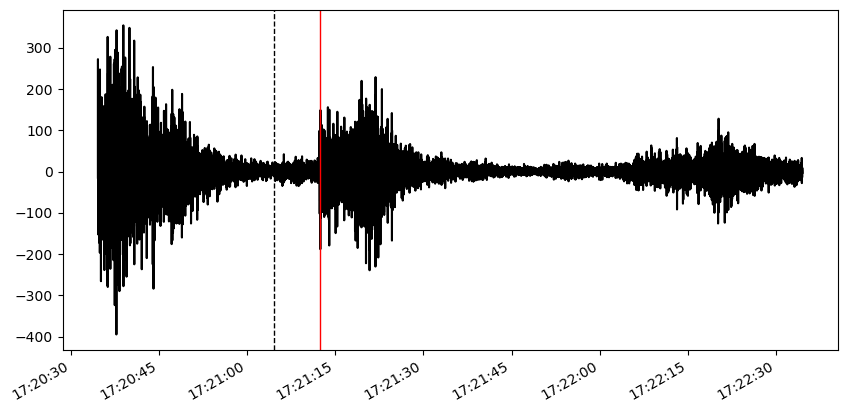

  0%|          | 10/371279 [00:00<11:41:17,  8.82it/s]

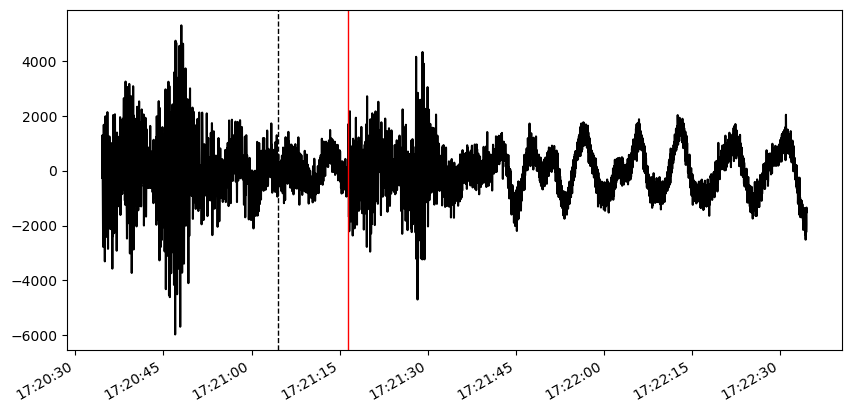

  0%|          | 26/371279 [00:02<7:28:38, 13.79it/s] 

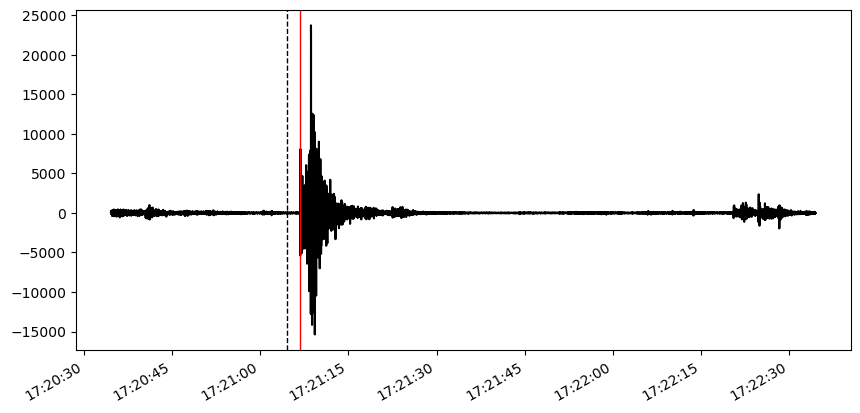

  0%|          | 28/371279 [00:02<11:23:39,  9.05it/s]

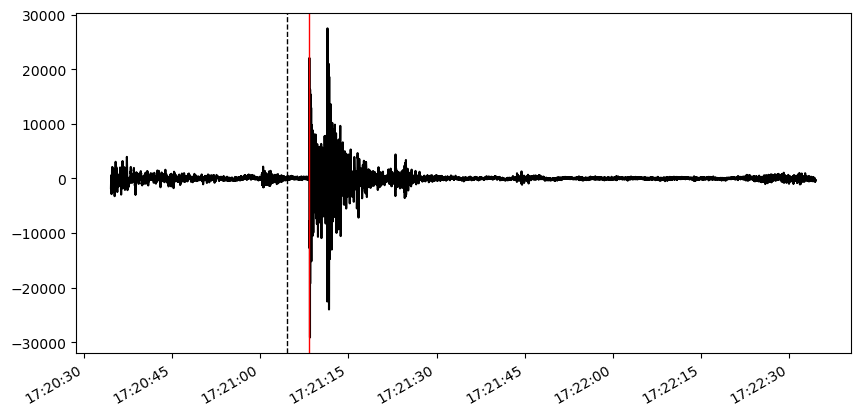

  0%|          | 38/371279 [00:03<7:50:36, 13.15it/s] 

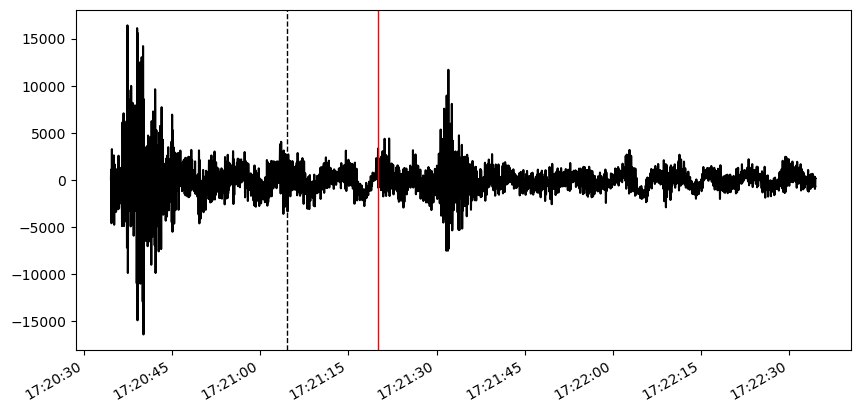

  0%|          | 42/371279 [00:03<9:10:31, 11.24it/s] 

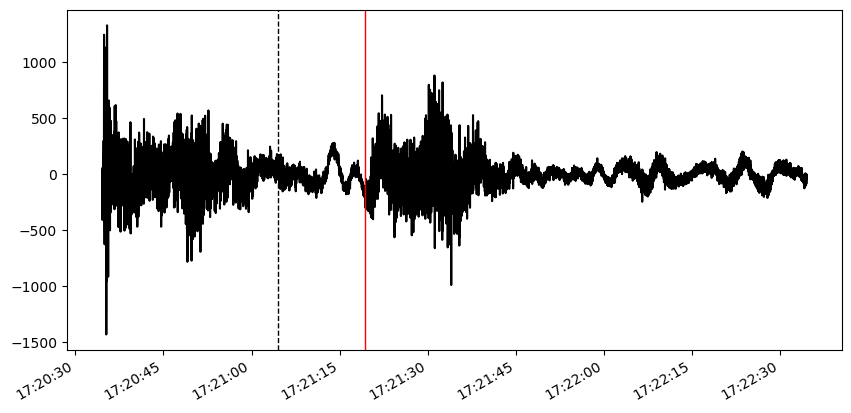

  0%|          | 70/371279 [00:05<6:39:46, 15.48it/s] 

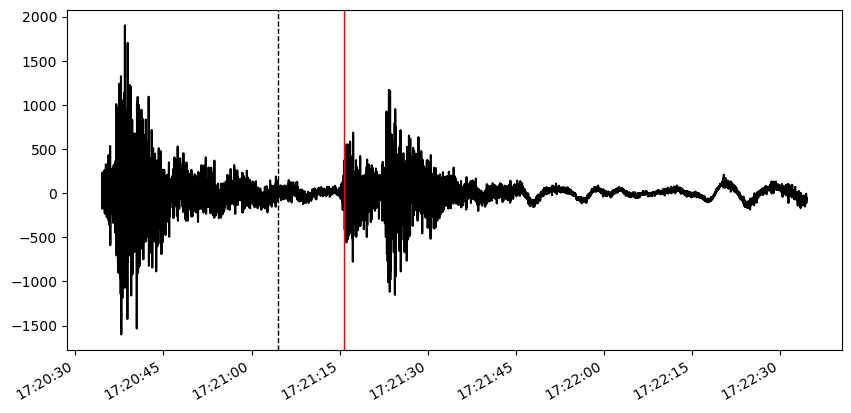

  0%|          | 100/371279 [00:07<6:12:03, 16.63it/s]

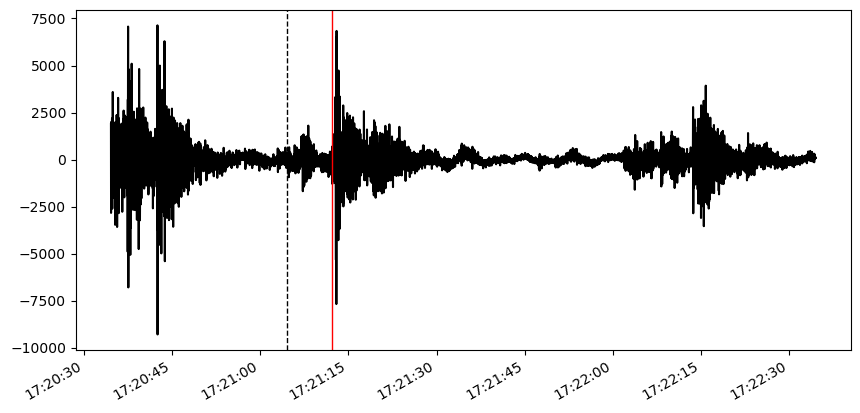

  0%|          | 102/371279 [00:08<8:47:13, 11.73it/s]

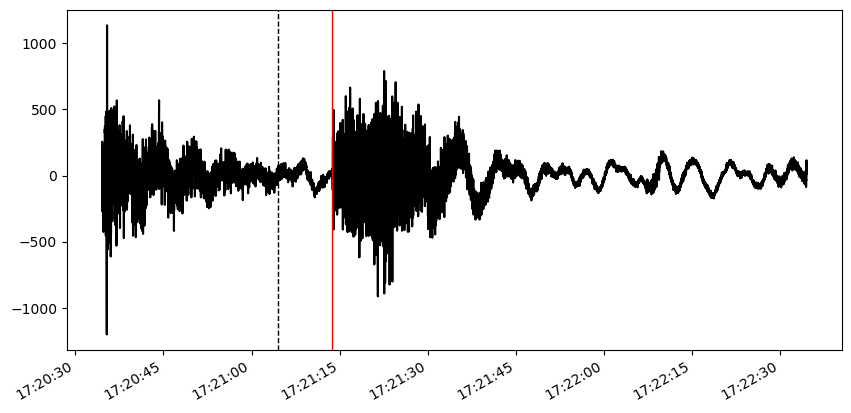

  0%|          | 104/371279 [00:08<10:42:52,  9.62it/s]

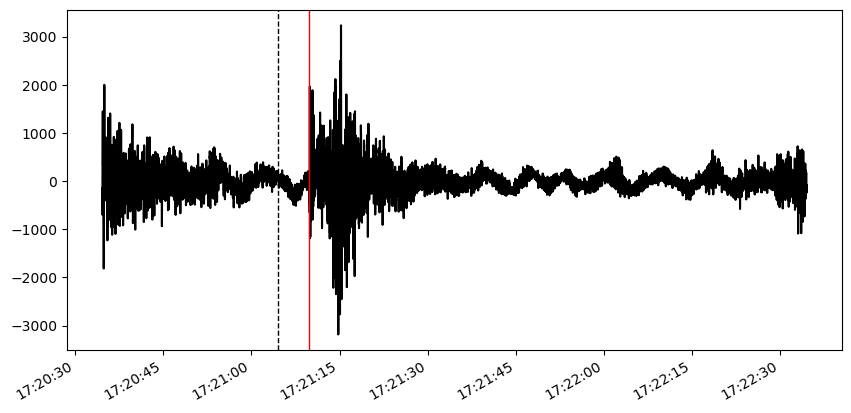

  0%|          | 110/371279 [00:08<9:16:16, 11.12it/s] 

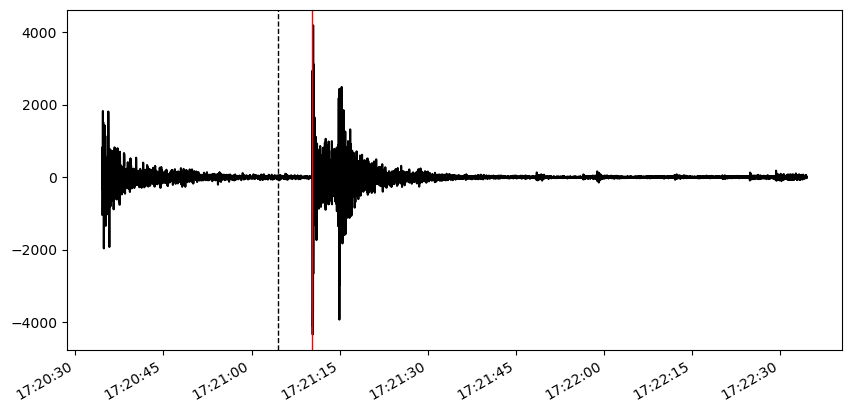

  0%|          | 111/371279 [00:09<8:34:27, 12.02it/s]


ValueError: 

In [202]:
assert len(seismogram_paths) == len(event_names)
n = 0
for i in trange(len(seismogram_paths)): 
    ev_id = event_names[i]
    st = read(seismogram_paths[i])
    assert len(st) == 1
    tr = st[0]
    st_id = tr.id
    npts = tr.stats.npts


    # find row index number in df that matches event_name, station_name
    df_row = df[(df['event_name'] == ev_id) & (df['station_name'] == st_id)]
    index = df_row.index[0]

    assert len(df_row) == 1

    origin_dt = df_row['etime'].values[0]
    pick_p_dt = df_row['p_arrival'].values[0]
    pick_s_dt = df_row['s_arrival'].values[0]


    # print(st_id, ev_id, seismogram_paths[i])
    # print(df_row)

    if df_row['p_arrival'].values[0] != datetime.datetime(1970, 1, 1, 0, 0):
        
        fig, ax = plt.subplots(1,1, figsize=(10,5))
        tr.detrend('linear')

        ax.plot(tr.times("matplotlib"), tr.data, c='k')
        ax.axvline(x=origin_dt, c='k', lw=1, ls='--')
        ax.axvline(x=pick_p_dt.datetime, c='r', lw=1)
        # ax.axvline(x=pick_s_dt, c='b', lw=1)
        ax.xaxis_date()
        fig.autofmt_xdate()
        plt.show()

        n += 1
        if n > 10:
            raise ValueError()


In [195]:
type(pick_p_dt)

obspy.core.utcdatetime.UTCDateTime

In [180]:
tr.stats.starttime.datetime

datetime.datetime(2019, 7, 8, 17, 20, 34, 553100)

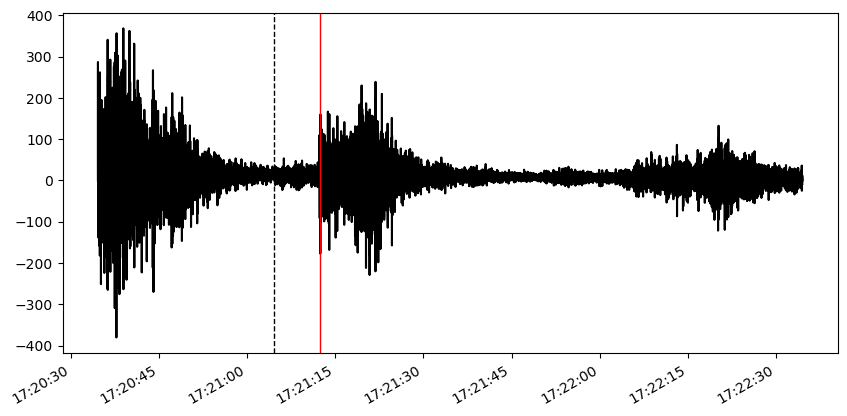

In [ ]:

fig, ax = plt.subplots(1,1, figsize=(10,5))
tr.detrend()

ax.plot(tr.times("matplotlib"), tr.data, c='k')
ax.axvline(x=origin_dt, c='k', lw=1, ls='--')
ax.axvline(x=pick_p_dt.datetime, c='r', lw=1)
# ax.axvline(x=pick_s_dt, c='b', lw=1)
ax.xaxis_date()
fig.autofmt_xdate()
plt.show()

In [141]:
seismogram_paths[i]

'/Volumes/ianhdd/LaCie/ridgecrest_data/RC_M2.0to2.5/38489455/AVM.CI.HNZ..2019.189.172104.38489455.ms'

In [144]:
len(event_names), len(seismogram_paths)

(371279, 371279)

In [135]:
st[i]

CI.APL..HNE | 2019-07-08T17:20:34.549900Z - 2019-07-08T17:22:34.549900Z | 100.0 Hz, 12001 samples

In [115]:
df.head(20)

,station_name,event_name,emag,elon,elat,edep,relocated,etime,p_arrival,s_arrival,slat,slon,sele,local_depth,sample_rate,sdip,sazi
0,CE.34349..HNE,37218988,4.28,-117.50593,35.6881,0.616,True,2019-07-04 17:35:52.115000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,90.0
1,CE.34349..HNE,38443183,6.4,-117.50383,35.70533,10.5,False,2019-07-04 17:33:49.000001,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,90.0
2,CE.34349..HNE,38443191,4.49,-117.56717,35.644,4.6,False,2019-07-04 17:35:01.660000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,90.0
3,CE.34349..HNE,38450263,5.36,-117.56916,35.76378,7.233,True,2019-07-05 11:07:53.246000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,90.0
4,CE.34349..HNE,38548295,4.9,-117.58533,35.63833,9.9,False,2019-07-12 13:11:37.980000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,90.0
5,CE.34349..HNN,37218988,4.28,-117.50593,35.6881,0.616,True,2019-07-04 17:35:52.115000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,0.0
6,CE.34349..HNN,38443183,6.4,-117.50383,35.70533,10.5,False,2019-07-04 17:33:49.000001,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,0.0
7,CE.34349..HNN,38443191,4.49,-117.56717,35.644,4.6,False,2019-07-04 17:35:01.660000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,0.0
8,CE.34349..HNN,38450263,5.36,-117.56916,35.76378,7.233,True,2019-07-05 11:07:53.246000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,0.0
9,CE.34349..HNN,38548295,4.9,-117.58533,35.63833,9.9,False,2019-07-12 13:11:37.980000,1970-01-01 00:00:00,1970-01-01 00:00:00,35.6156,-118.4784,754.0,0.0,200.0,0.0,0.0


In [113]:
st

203 Trace(s) in Stream:

CI.APL..HNE | 2019-07-08T17:20:34.549900Z - 2019-07-08T17:22:34.549900Z | 100.0 Hz, 12001 samples
...
(201 other traces)
...
CI.WOR..HNZ | 2019-07-08T17:20:34.558300Z - 2019-07-08T17:22:34.548300Z | 100.0 Hz, 12000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]